In [1]:
import gmsh
import ufl
import pyvista as pv
import numpy as np
import imageio.v2 as imageio
import dolfinx.io as dio
import adios4dolfinx

from IPython.display import Image, display
from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, plot
from dolfinx.fem import Constant, Function
from dolfinx.fem.petsc import LinearProblem
from basix.ufl import element, mixed_element
from petsc4py import PETSc


In [2]:
y_lim = 1.0
x_lim = 2.0

meshfile = Path("../../meshes/rectangle_circular_holes/mesh.msh").resolve()

domain, cell_tags, facet_tags = dio.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)

# Get tags of physical groups
gmsh.initialize()
gmsh.open(str(meshfile))
phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

print(name_to_id)

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 835 nodes
Info    : 1678 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 835 nodes
Info    : 1678 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
{'Inflow': 2, 'Outflow': 3, 'Walls': 4, 'Obstacle1': 5, 'Obstacle2': 6, 'Obstacle3': 7, 'Obstacle4': 8, 'Obstacle5': 9, 'Volume': 1}


In [3]:
# Elements and spaces
elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

mixed_elem = mixed_element([elem_u, elem_p])
W = fem.functionspace(domain, mixed_elem)

In [4]:
# No slip boundary conditions
W0 = W.sub(0)
V, V_to_W0 = W0.collapse()

u_D_no_slip = fem.Function(V)
u_D_no_slip.x.array[:] = 0.0
no_slip_names = ["Walls", "Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
dofs_local = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs = fem.locate_dofs_topological((W0, V), V.mesh.topology.dim - 1, dofs_local)
bc_no_slip = fem.dirichletbc(u_D_no_slip, dofs, W0)

def visualize_mixed(mixed_function: fem.Function, scale=1.0):
    u_c = mixed_function.sub(0).collapse()
    p_c = mixed_function.sub(1).collapse()

    u_grid = pv.UnstructuredGrid(*plot.vtk_mesh(u_c.function_space))

    # Pad u to be 3D
    gdim = u_c.function_space.mesh.geometry.dim
    assert len(u_c) == gdim
    u_values = np.zeros((len(u_c.x.array) // gdim, 3), dtype=np.float64)
    u_values[:, :gdim] = u_c.x.array.real.reshape((-1, gdim))

    # Create a point cloud of glyphs
    u_grid["u"] = u_values
    glyphs = u_grid.glyph(orient="u", factor=scale)
    plotter = pv.Plotter()
    plotter.add_mesh(u_grid, show_edges=False, show_scalar_bar=False)
    plotter.add_mesh(glyphs)
    plotter.view_xy()
    plotter.show()

    p_grid = pv.UnstructuredGrid(*plot.vtk_mesh(p_c.function_space))
    p_grid.point_data["p"] = p_c.x.array
    plotter_p = pv.Plotter()
    plotter_p.add_mesh(p_grid, show_edges=False)
    plotter_p.view_xy()
    plotter_p.show()

# tmp_wh = fem.Function(W)
# bc_no_slip.set(tmp_wh.x.array)
# tmp_wh.x.scatter_forward()
# visualize_mixed(tmp_wh)

# Inflow
def parabolic_inflow_profile(x: np.ndarray) -> np.ndarray:
    vmax = 0.5
    v_x = vmax * 4.0 * (x[1] / y_lim) * (1.0 - x[1] / y_lim) * np.ones_like(x[0])
    v_y = np.zeros_like(x[1]) 

    return np.stack((v_x, v_y))

u_D_inflow = fem.Function(V)
u_D_inflow.interpolate(parabolic_inflow_profile)
u_inflow = np.array((0.2, 0.0) , dtype=PETSc.ScalarType)
dofs_local = facet_tags.find(name_to_id["Inflow"])
dofs_in = fem.locate_dofs_topological((W0, V), V.mesh.topology.dim - 1, dofs_local)

bc_inflow = fem.dirichletbc(u_D_inflow, dofs_in, W0)

# wh_tmp = fem.Function(W)
# bc_inflow.set(wh_tmp.x.array)
# wh_tmp.x.scatter_forward()
# visualize_mixed(wh_tmp)

# Outflow
W1 = W.sub(1)
Q, Q_to_W1 = W1.collapse()
p_zero = fem.Function(Q)
p_zero.x.array[:] = 0.0
dofs_local = facet_tags.find(name_to_id["Outflow"])
dofs_out = fem.locate_dofs_topological((W1, Q), V.mesh.topology.dim - 1, dofs_local)

bc_out = fem.dirichletbc(p_zero, dofs_out, W1)

# wh_tmp = fem.Function(W)
# bc_out.set(wh_tmp.x.array)
# wh_tmp.x.scatter_forward()
# visualize_mixed(wh_tmp)

In [5]:
# Prepare visualization
topology, cell_type, geom = plot.vtk_mesh(domain) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

V_u_vis = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1, shape=(domain.topology.dim,)))
u_vis = Function(V_u_vis)

In [6]:
frames = []

(u, p) = ufl.TrialFunctions(W)
(v, q) = ufl.TestFunctions(W)

wh = fem.Function(W)

wh_prev = fem.Function(W)
uh_prev, ph_prev = ufl.split(wh_prev)

wh_prev.sub(0).x.array[:] = 0.0
wh_prev.sub(1).x.array[:] = 0.0

max_picard = 20
tol_picard = 1e-3
omega = 0.3
nu = Constant(domain, 1.5e-4)

# SUPG params
h = ufl.CellDiameter(domain)
abs_u_prev = ufl.sqrt(ufl.dot(uh_prev, uh_prev)) + 1e-12
tau = 1.0 / ( (2.0 * abs_u_prev) / h + 4.0 * nu / (h*h) + 1e-8 )

# Picard linearization
a_nav_stokes = ( nu * ufl.inner(ufl.nabla_grad(u), ufl.nabla_grad(v))
                + ufl.inner(ufl.dot(uh_prev, ufl.nabla_grad(u)), v)
                - ufl.inner(p, ufl.div(v))
                + ufl.inner(ufl.div(u), q) ) * ufl.dx
Rm_trial = ufl.dot(uh_prev, ufl.nabla_grad(u)) - nu * ufl.div(ufl.nabla_grad(u)) + ufl.nabla_grad(p)
supg = tau * ufl.inner(ufl.dot(uh_prev, ufl.nabla_grad(v)), Rm_trial) * ufl.dx

a_picard = a_nav_stokes + supg

L_picard = ufl.inner(fem.Constant(domain, PETSc.ScalarType((0.0, 0.0))), v) * ufl.dx

for k in range(max_picard):
    prob = LinearProblem(a_picard, L_picard, 
                         [bc_no_slip, bc_inflow, bc_out],
                         petsc_options={"ksp_type": "gmres", "pc_type": "lu",
                                        "ksp_rtol": 1e-8, "ksp_max_it": 20,
                                        "ksp_monitor": None
                                        })
    wh = prob.solve()

    # Damped solution update
    wh.x.array[:] = (1 - omega) * wh_prev.x.array + omega * wh.x.array

    # Compute L2 norm of step: sqrt( ∫ |u_new - u_old|^2 dx )
    diff_u = wh.sub(0) - wh_prev.sub(0)
    l2_step_sq = fem.assemble_scalar(fem.form(ufl.inner(diff_u, diff_u) * ufl.dx))
    l2_step = np.sqrt(l2_step_sq)
    norm_new_sq = fem.assemble_scalar(fem.form(ufl.inner(wh.sub(0), wh.sub(0)) * ufl.dx))
    rel_step = l2_step / (np.sqrt(norm_new_sq) + 1e-12)
    print(f"It {k}: Rel L2 step = {rel_step:.3e}")

    # Visualize
    u_vis.interpolate(wh.sub(0))
    wind2d = u_vis.x.array.reshape(-1, 2)
    wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
    grid.point_data["wind_vectors"] = wind3d
    glyphs = grid.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

    pl = pv.Plotter(off_screen=True)
    pl.add_mesh(glyphs, scalar_bar_args={"title": f"Airflow speed (m/s): Iter {k}"})
    pl.add_mesh(grid, color='k', opacity=0.3)
    pl.view_xy()
    pl.zoom_camera(1.3)

    img = pl.screenshot(return_img=True)
    frames.append(img)
    pl.close()

    # Stopping criteria
    if rel_step < tol_picard:
        print("Picard converged.")
        break

    wh_prev.x.array[:] = wh.x.array[:]

  Residual norms for dolfinx_solve_140541066799632 solve.
  0 KSP Residual norm 2.642678524745e+01
  1 KSP Residual norm 3.636163624719e-14
It 0: Rel L2 step = 1.000e+00
  Residual norms for dolfinx_solve_140540474586768 solve.
  0 KSP Residual norm 2.418026487218e+01
  1 KSP Residual norm 7.183835069080e-14
It 1: Rel L2 step = 4.332e-01
  Residual norms for dolfinx_solve_140540471155664 solve.
  0 KSP Residual norm 2.479891473548e+01
  1 KSP Residual norm 7.368138797256e-14
It 2: Rel L2 step = 2.703e-01
  Residual norms for dolfinx_solve_140540477513488 solve.
  0 KSP Residual norm 2.504604133134e+01
  1 KSP Residual norm 7.996016489014e-14
It 3: Rel L2 step = 1.796e-01
  Residual norms for dolfinx_solve_140540474463312 solve.
  0 KSP Residual norm 2.537330607926e+01
  1 KSP Residual norm 1.002911941541e-13
It 4: Rel L2 step = 1.320e-01
  Residual norms for dolfinx_solve_140540478541392 solve.
  0 KSP Residual norm 2.581897127419e+01
  1 KSP Residual norm 8.389430571816e-14
It 5: Rel 

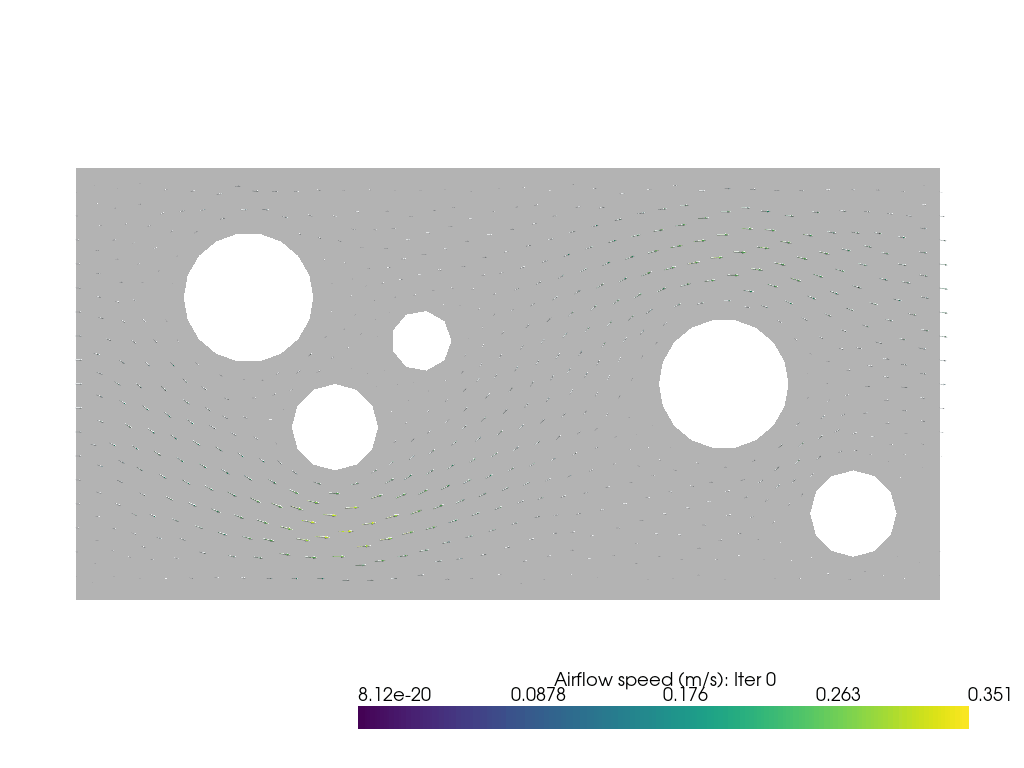

In [7]:
# --- GIF im Speicher erzeugen ---
gif_path = "picard_iterations.gif"
imageio.mimsave(gif_path, frames, fps=2)

# --- Direkt im Notebook anzeigen ---
display(Image(filename=gif_path))

In [8]:
# Estimate Reynolds number
U = np.max(u_D_inflow.x.array)
L = max(x_lim, y_lim)
nu_val = nu.value
Re = U * L / nu_val
print("Re ≈", Re)

Re ≈ 6666.666666666667


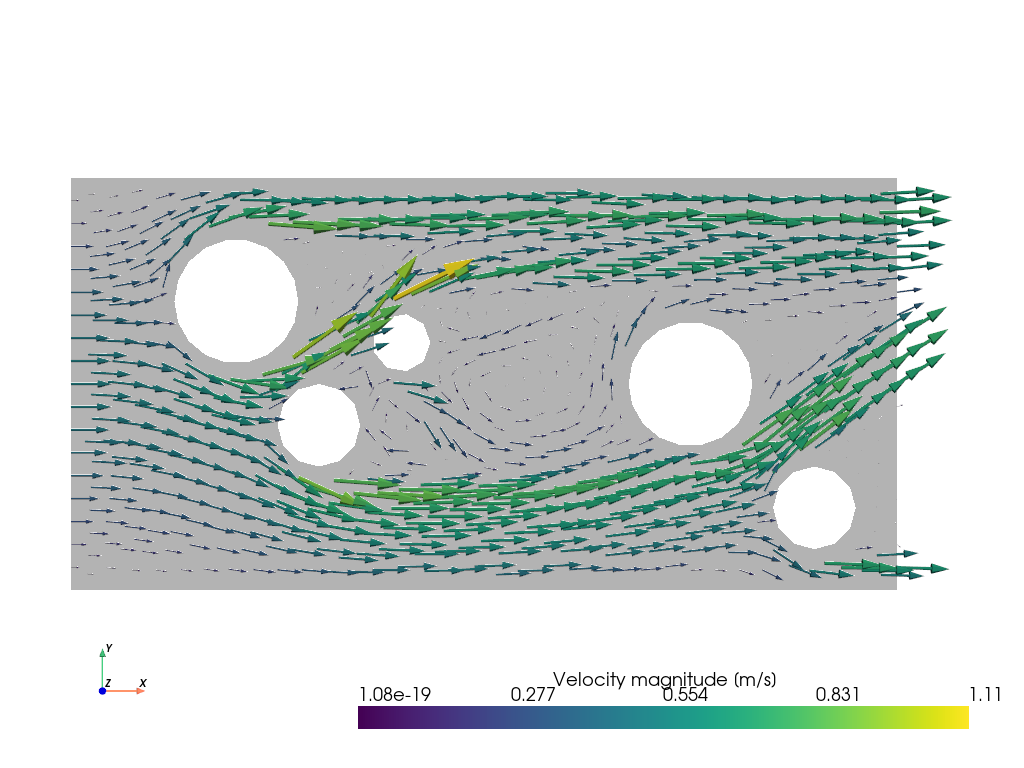

In [9]:
# Visualize final iteration
u_vis.interpolate(wh.sub(0))

wind2d = u_vis.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d
glyphs = grid.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.2)

pl = pv.Plotter()
pl.add_mesh(glyphs, scalar_bar_args={"title": "Velocity magnitude [m/s]"})
pl.add_mesh(grid, color='k', opacity=0.3)
pl.view_xy()
pl.zoom_camera(1.3)
pl.show_axes()
pl.show()

In [10]:
# Save final iteration to bp file
wind_file = Path("../wind_data/airflow_picard.bp")
adios4dolfinx.write_mesh(wind_file, domain)
adios4dolfinx.write_meshtags(wind_file, domain, facet_tags, meshtag_name="facet_tags")
adios4dolfinx.write_function(wind_file, u_vis, name="velocity_H1")
adios4dolfinx.write_function(wind_file, wh.sub(0).collapse(), name="velocity_H2")